The objective of this notebook is to create an end-to-end flood prediction pipeline using the trained autoencoder and Random Forest classifier. A new SAR image is loaded, preprocessed, converted into latent features using the encoder, and then passed to the trained classifier to predict whether the image contains flooded regions. This notebook serves as the foundation for the future web dashboard, where uploaded SAR images will be automatically analyzed and classified as flood-prone or non-flood-prone.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model, Model

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/sar-project/models"
TEST_IMAGE_DIR = "/content/drive/MyDrive/sar-project/test_images"

In [5]:
print(os.listdir(MODEL_DIR))

['random_forest_flood_classifier.pkl', 'autoencoder.h5']


In [7]:
#LOAD AUTOENCODER
from tensorflow import keras

autoencoder = keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "autoencoder.h5"
    ),
    custom_objects={'mse': keras.metrics.MeanSquaredError()}
)
print("Autoencoder Loaded")

Autoencoder Loaded


In [8]:
#BUILD ENCODER
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer(
        "latent_space"
    ).output
)
print("Encoder Created")

Encoder Created


In [9]:
#LOAD RANDOM FOREST MODEL
rf_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "random_forest_flood_classifier.pkl"
    )
)

print("Random Forest Loaded")

Random Forest Loaded


In [13]:
test_image_path = (
    "/content/drive/MyDrive/sar-project/sar_test_images/testimg.jpeg"
)

In [14]:
#READ SAR IMAGE
if not os.path.exists(test_image_path):
    print(f"Error: Image file not found at {test_image_path}")
    img = None # Ensure img is None if file not found
else:
    img = cv2.imread(
        test_image_path,
        cv2.IMREAD_GRAYSCALE
    )

if img is not None:
    print(img.shape)
else:
    print("Error: Could not load image. Check the file path and image integrity.")

(232, 217)


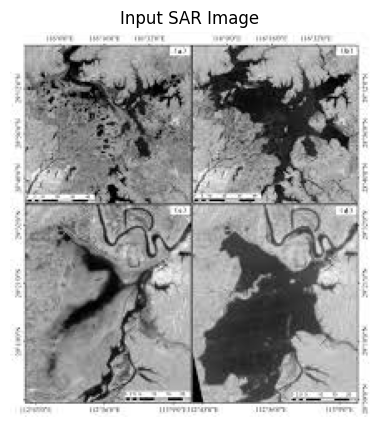

In [15]:
#DISPLAY ORIGINAL IMAGE
plt.figure(figsize=(5,5))
plt.imshow(
    img,
    cmap="gray"
)
plt.title("Input SAR Image")
plt.axis("off")
plt.show()

In [16]:
#RESIZING IMAGE
img = cv2.resize(
    img,
    (128,128)
)
print(img.shape)

(128, 128)


In [17]:
#NORMALIZE
img = img.astype(np.float32)
img = img / 255.0

In [18]:
#ADD CHANNEL DIMENSION
img = np.expand_dims(
    img,
    axis=-1
)

In [19]:
#ADD BATCH DIMNENSION
img = np.expand_dims(
    img,
    axis=0
)
print(img.shape)

(1, 128, 128, 1)


In [20]:
#EXTRACT LETENT FEATURES
latent_features = encoder.predict(
    img
)
print(latent_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
(1, 32, 32, 16)


In [22]:
#FLATTEN FEATURES
latent_flat = latent_features.reshape(
    latent_features.shape[0],
    -1
)
print(latent_flat.shape)

(1, 16384)


In [23]:
#PREDICT FLOOD
prediction = rf_model.predict(
    latent_flat
)
print(prediction)

[0]


In [24]:
#DISPLAY RESULT
if prediction[0] == 1:
    print(
        "⚠️ Flood-Prone Area Detected"
    )
else:
    print(
        "✅ No Flood Detected"
    )

✅ No Flood Detected


In [25]:
#PREDICTION PROBABILITY
probability = rf_model.predict_proba(
    latent_flat
)
print(probability)

[[0.56661499 0.43338501]]


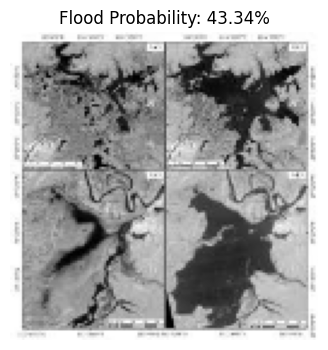

In [26]:
#VISUAL RESULT
flood_prob = probability[0][1] * 100
plt.figure(figsize=(6,4))
plt.imshow(
    img[0].squeeze(),
    cmap="gray"
)
plt.title(
    f"Flood Probability: {flood_prob:.2f}%"
)
plt.axis("off")
plt.show()

In [27]:
#SAVE PREDICTION REPORT
result = {
    "Prediction":
        "Flood"
        if prediction[0] == 1
        else "No Flood",

    "Flood Probability":
        float(flood_prob)
}
print(result)

{'Prediction': 'No Flood', 'Flood Probability': 43.33850079744816}
